# Project 3 — Multimodal BEV Perception

**Experiment ID:** P3-4  
**Architecture:** Multimodal Fusion +  Hybrid Cross-Attention  
**Task:** BEV Occupancy Prediction  
**Dataset:** nuScenes-mini

## Objective

This notebook develops and evaluates the final multimodal
fusion architectures for BEV occupancy prediction using
RGB images, LiDAR BEV representations, and IMU
measurements.



In [4]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
assets	     colab_packages  deployment  notebooks_final  reports  src
checkpoints  data	     notebooks	 nuscenes	  results


In [5]:
import os, sys
# --- System ---
sys.path.append('/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/colab_packages')


In [6]:
import sys, os, importlib
# Make sure your src/ directory is visible to Python
project_root = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception"
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    print(f" Added to sys.path: {src_path}")

# Clear any stale caches
importlib.invalidate_caches()

# Environment Setup

This section mounts Google Drive, configures the Python
environment, and imports the project source code required
for training and evaluation.

The runtime is configured to use GPU acceleration when
available.

In [7]:
# ============================================================
# Imports and Runtime Configuration
# ============================================================

import os
import time

import numpy as np
import torch
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.dataset_utils import RGBBEVDataset
from src.losses import HybridLoss
from src.model.fusion_hybrid_xattn import (
    FusionHybridXAttentionModel,
)
from src.report_utils import save_report


# ============================================================
# Device Configuration
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {device}")

if torch.cuda.is_available():

    print(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )


# ============================================================
# Runtime Configuration
#
# Enable cuDNN benchmarking to select the fastest
# convolution algorithms when the input resolution
# remains constant throughout training.
# ============================================================

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


# Data Preparation

The preprocessed multimodal dataset is loaded from HDF5
files generated during the preprocessing stage.

An 80/20 train-validation split is constructed and
wrapped in PyTorch DataLoaders for efficient mini-batch
training.

In [8]:
# ============================================================
# Dataset Preparation
#
# Load the preprocessed multimodal RGB–LiDAR–IMU dataset,
# perform an 80/20 train-validation split, and construct
# PyTorch DataLoaders for the Hybrid X-Attention experiment.
# ============================================================

# ---------------------------------------------------
# Dataset location
# ---------------------------------------------------
data_dir = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "project3_multimodal_bev_perception/"
    "data/preprocessed_moving"
)

# ---------------------------------------------------
# Discover all HDF5 samples
# ---------------------------------------------------
files = sorted(
    [
        os.path.join(data_dir, filename)
        for filename in os.listdir(data_dir)
        if filename.endswith(".h5")
    ]
)

print(
    f"Found {len(files)} HDF5 files in:\n{data_dir}"
)

# ---------------------------------------------------
# Train / Validation split (80 / 20)
# ---------------------------------------------------
split_idx = int(
    0.8 * len(files)
)

train_files = files[:split_idx]
val_files = files[split_idx:]

# ---------------------------------------------------
# Dataset objects
# ---------------------------------------------------
train_set = RGBBEVDataset(
    train_files,
)

val_set = RGBBEVDataset(
    val_files,
)

# ---------------------------------------------------
# DataLoaders
# ---------------------------------------------------
BATCH_SIZE = 8

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

# ---------------------------------------------------
# Verify one training sample
# ---------------------------------------------------
rgb, bev, imu = train_set[0]

print("\nSample tensor shapes")
print("--------------------")
print(f"RGB Input : {tuple(rgb.shape)}")
print(f"LiDAR BEV : {tuple(bev.shape)}")
print(f"IMU       : {tuple(imu.shape)}")

print("\nDataset summary")
print("----------------")
print(f"Training samples   : {len(train_set)}")
print(f"Validation samples : {len(val_set)}")
print(f"Batch size         : {BATCH_SIZE}")

Found 323 HDF5 files in:
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/data/preprocessed_moving

Sample tensor shapes
--------------------
RGB Input : (3, 256, 256)
LiDAR BEV : (1, 200, 200)
IMU       : (10, 6)

Dataset summary
----------------
Training samples   : 258
Validation samples : 65
Batch size         : 8


# Model Initialization

This section instantiates the selected multimodal fusion
architecture, defines the training objective, and
configures the optimizer used during learning.

The experiment is:
- Fusion + Hybrid X-Attention

In [9]:
# ============================================================
# Model Initialization
#
# Instantiate the Fusion + Hybrid X-Attention model,
# define the optimization objective, and configure
# the optimizer used for training.
# ============================================================

# ---------------------------------------------------
# Model
# ---------------------------------------------------
model = FusionHybridXAttentionModel().to(
    device,
)

# Uncomment to inspect the architecture
# print(model)

# ---------------------------------------------------
# Loss function
# ---------------------------------------------------
loss_fn = HybridLoss()

# ---------------------------------------------------
# Optimizer
# ---------------------------------------------------
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5,
)

# ---------------------------------------------------
# Model summary
# ---------------------------------------------------
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Fusion + Hybrid X-Attention")
print("-" * 36)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Fusion + Hybrid X-Attention
------------------------------------
Total parameters     : 546,161
Trainable parameters : 546,161


# Model Training

Each model is trained using the HybridLoss objective.

Training progress is monitored using validation
Intersection-over-Union (IoU), and the checkpoint with
the highest validation IoU is retained for subsequent
evaluation.

In [ ]:
# ============================================================
# Training
#
# Train the Fusion + Hybrid X-Attention model using
# HybridLoss and monitor validation IoU to retain the
# best-performing checkpoint.
# ============================================================

def soft_iou(
    pred,
    target,
    smooth=1e-6,
):
    """
    Compute the mean binary Intersection-over-Union (IoU)
    between predicted and ground-truth BEV occupancy maps.
    """

    pred_bin = (pred > 0.5).float()

    intersection = (
        pred_bin * target
    ).sum(dim=(2, 3))

    union = (
        pred_bin.sum(dim=(2, 3))
        + target.sum(dim=(2, 3))
        - intersection
    )

    return (
        (intersection + smooth)
        / (union + smooth)
    ).mean().item()


# ---------------------------------------------------
# Training configuration
# ---------------------------------------------------
EPOCHS = 40

best_val_iou = 0.0

t0 = time.time()


# ---------------------------------------------------
# Training loop
# ---------------------------------------------------
for epoch in range(EPOCHS):

    model.train()

    train_loss = 0.0

    for rgb, bev, imu in tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}",
        ncols=90,
    ):

        rgb = rgb.to(device)
        bev = bev.to(device)
        imu = imu.to(device)

        logits = model(
            rgb,
            bev,
            imu,
        )

        # ---------------------------------------------------
        # Resize the ground-truth BEV map if the prediction
        # resolution differs from the model output.
        # ---------------------------------------------------
        if bev.shape[-2:] != logits.shape[-2:]:

            bev = F.interpolate(
                bev,
                size=logits.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        loss = loss_fn(
            logits,
            bev,
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------------------------------------------------
    # Validation
    # ---------------------------------------------------
    model.eval()

    val_loss = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for rgb, bev, imu in val_loader:

            rgb = rgb.to(device)
            bev = bev.to(device)
            imu = imu.to(device)

            logits = model(
                rgb,
                bev,
                imu,
            )

            if bev.shape[-2:] != logits.shape[-2:]:

                bev = F.interpolate(
                    bev,
                    size=logits.shape[-2:],
                    mode="bilinear",
                    align_corners=False,
                )

            val_loss += loss_fn(
                logits,
                bev,
            ).item()

            val_iou += soft_iou(
                logits,
                bev,
            )

    val_loss /= len(val_loader)

    val_iou /= len(val_loader)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f}"
    )

    # ---------------------------------------------------
    # Save the checkpoint with the highest validation IoU.
    # ---------------------------------------------------
    if val_iou > best_val_iou:

        best_val_iou = val_iou

        os.makedirs(
            "checkpoints",
            exist_ok=True,
        )

        torch.save(
            model.state_dict(),
            "checkpoints/fusion_hybrid_xattn_best.pth",
        )


# ---------------------------------------------------
# Training summary
# ---------------------------------------------------
t1 = time.time()

print(
    "\nTraining complete."
)

print(
    f"Best Validation IoU : {best_val_iou:.4f}"
)

print(
    f"Training time       : {(t1 - t0) / 60:.2f} minutes"
)

Epoch 1/40: 100%|█████████████████████████████████████████| 33/33 [00:44<00:00,  1.35s/it]


Epoch 01/40 | Train Loss: 0.6312 | Val Loss: 0.5716 | Val IoU: 0.3914


Epoch 2/40: 100%|█████████████████████████████████████████| 33/33 [00:02<00:00, 15.89it/s]


Epoch 02/40 | Train Loss: 0.5728 | Val Loss: 0.5478 | Val IoU: 0.4154


Epoch 3/40: 100%|█████████████████████████████████████████| 33/33 [00:02<00:00, 15.84it/s]


...

Epoch 38/40 | Train Loss: 0.3495 | Val Loss: 0.3397 | Val IoU: 0.5554


Epoch 39/40: 100%|████████████████████████████████████████| 33/33 [00:02<00:00, 15.50it/s]


Epoch 39/40 | Train Loss: 0.3455 | Val Loss: 0.3372 | Val IoU: 0.5573


Epoch 40/40: 100%|████████████████████████████████████████| 33/33 [00:02<00:00, 15.33it/s]


Epoch 40/40 | Train Loss: 0.3412 | Val Loss: 0.3327 | Val IoU: 0.5586

Training complete.
Best Validation IoU : 0.5586
Training time       : 2.68 minutes


# Quantitative Evaluation

The best-performing checkpoint is evaluated on the
validation set using standard binary occupancy
segmentation metrics.

Reported metrics include:

- Mean IoU
- Precision
- Recall
- F1 Score

In [ ]:
# ============================================================
# Quantitative Evaluation
#
# Evaluate the best-performing Fusion + Hybrid X-Attention
# model on the validation dataset using standard binary
# BEV occupancy segmentation metrics.
#
# Metrics
#   • Mean IoU
#   • Mean Precision
#   • Mean Recall
#   • Mean F1 Score
# ============================================================


def compute_metrics(
    pred,
    target,
    thresh=0.5,
):
    """
    Compute binary segmentation metrics for a single
    BEV occupancy prediction.

    Parameters
    ----------
    pred : ndarray
        Predicted probability map.

    target : ndarray
        Ground-truth occupancy map.

    thresh : float, default=0.5
        Threshold used to obtain a binary prediction.

    Returns
    -------
    tuple
        (IoU, Precision, Recall, F1 Score)
    """

    pred_bin = (
        pred > thresh
    ).astype(np.uint8)

    target_bin = (
        target > 0.5
    ).astype(np.uint8)

    tp = np.logical_and(
        pred_bin == 1,
        target_bin == 1,
    ).sum()

    fp = np.logical_and(
        pred_bin == 1,
        target_bin == 0,
    ).sum()

    fn = np.logical_and(
        pred_bin == 0,
        target_bin == 1,
    ).sum()

    precision = tp / (tp + fp + 1e-6)

    recall = tp / (tp + fn + 1e-6)

    f1 = (
        2 * precision * recall
        / (precision + recall + 1e-6)
    )

    intersection = np.logical_and(
        pred_bin,
        target_bin,
    ).sum()

    union = np.logical_or(
        pred_bin,
        target_bin,
    ).sum()

    iou = intersection / (union + 1e-6)

    return (
        iou,
        precision,
        recall,
        f1,
    )


# ---------------------------------------------------
# Load best checkpoint
# ---------------------------------------------------
model.load_state_dict(
    torch.load(
        "checkpoints/fusion_hybrid_xattn_best.pth",
        map_location=device,
    )
)

model.eval()


# ---------------------------------------------------
# Evaluate validation set
# ---------------------------------------------------
iou_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

with torch.no_grad():

    for rgb, bev, imu in val_loader:

        rgb = rgb.to(device)
        bev = bev.to(device)
        imu = imu.to(device)

        logits = model(
            rgb,
            bev,
            imu,
        )

        # ---------------------------------------------------
        # Match the prediction resolution to the
        # ground-truth BEV occupancy map.
        # ---------------------------------------------------
        if logits.shape[-2:] != bev.shape[-2:]:

            logits = F.interpolate(
                logits,
                size=bev.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        probs = torch.sigmoid(
            logits
        )

        pred_np = probs.cpu().numpy()
        bev_np = bev.cpu().numpy()

        for pred, target in zip(
            pred_np,
            bev_np,
        ):

            iou, precision, recall, f1 = compute_metrics(
                pred[0],
                target[0],
            )

            iou_scores.append(iou)
            precision_scores.append(precision)
            recall_scores.append(recall)
            f1_scores.append(f1)


# ---------------------------------------------------
# Aggregate results
# ---------------------------------------------------
summary_dict = {
    "Mean IoU": np.mean(iou_scores),
    "Mean Precision": np.mean(precision_scores),
    "Mean Recall": np.mean(recall_scores),
    "Mean F1": np.mean(f1_scores),
}


print("\nValidation Performance")
print("----------------------")

for metric, value in summary_dict.items():

    print(
        f"{metric:<17}: {value:.4f}"
    )


# ---------------------------------------------------
# Save experiment report
# ---------------------------------------------------
save_report(
    summary_dict,
    model_name="FusionHybridXAttentionModel (RGB + LiDAR + IMU)",
    best_iou=summary_dict["Mean IoU"],
    start_time=t0,
    end_time=t1,
    auto_update=True,
)


Validation Performance
----------------------
Mean IoU         : 0.6017
Mean Precision   : 0.6497
Mean Recall      : 0.8906
Mean F1          : 0.7511
 Markdown report saved → reports/fusionhybridxattentionmodel_rgb___lidar___imu_summary.md
 CSV report saved → reports/fusionhybridxattentionmodel_rgb___lidar___imu_summary.csv
 Leaderboard saved → reports/leaderboard.csv
️ Markdown summary → reports/leaderboard.md
 Leaderboard plot saved → reports/leaderboard.png


('reports/fusionhybridxattentionmodel_rgb___lidar___imu_summary.md',
 'reports/fusionhybridxattentionmodel_rgb___lidar___imu_summary.csv')

# Qualitative Evaluation

Representative validation samples are visualized to
provide an intuitive assessment of segmentation quality.

For each sample, the following are displayed:

- RGB input
- Ground-truth BEV occupancy map
- Predicted occupancy map
- Binary error map

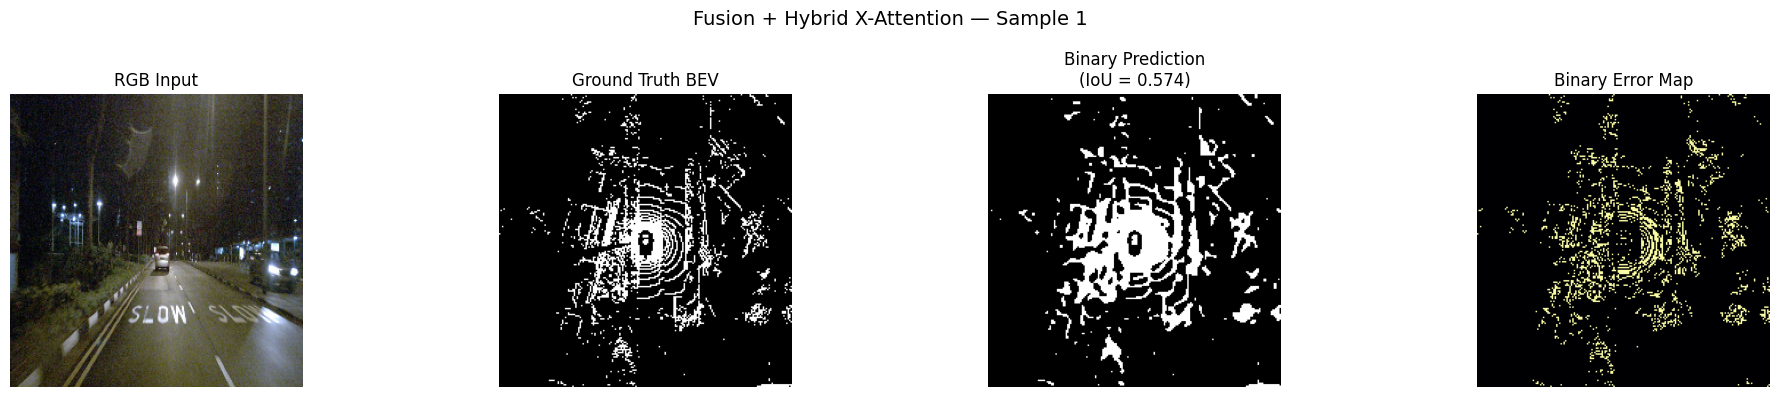

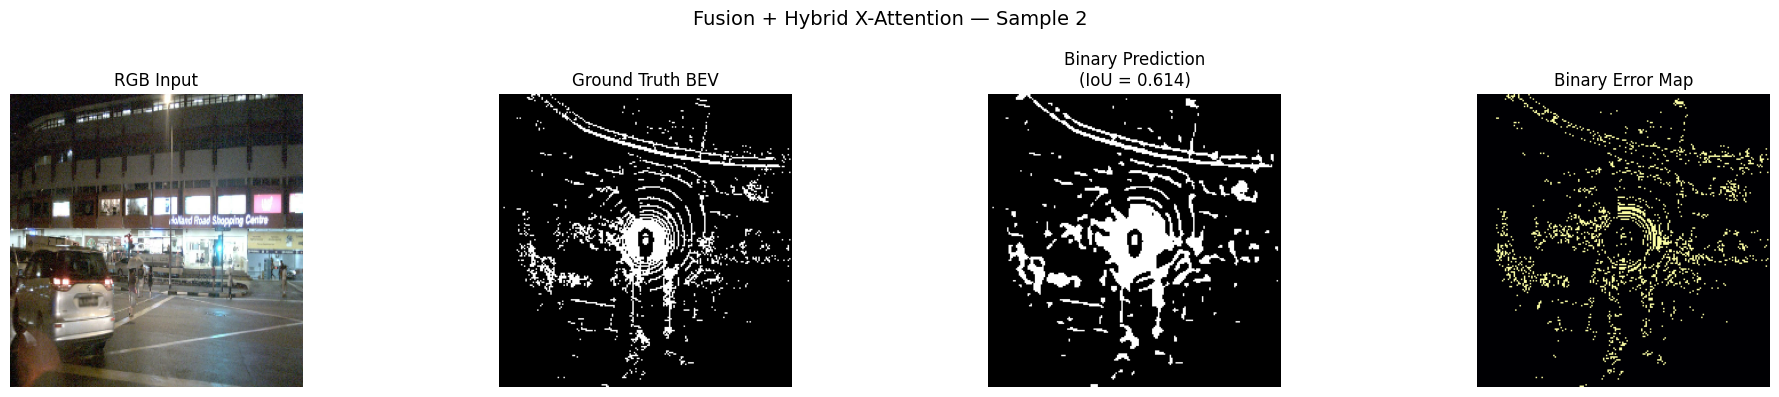

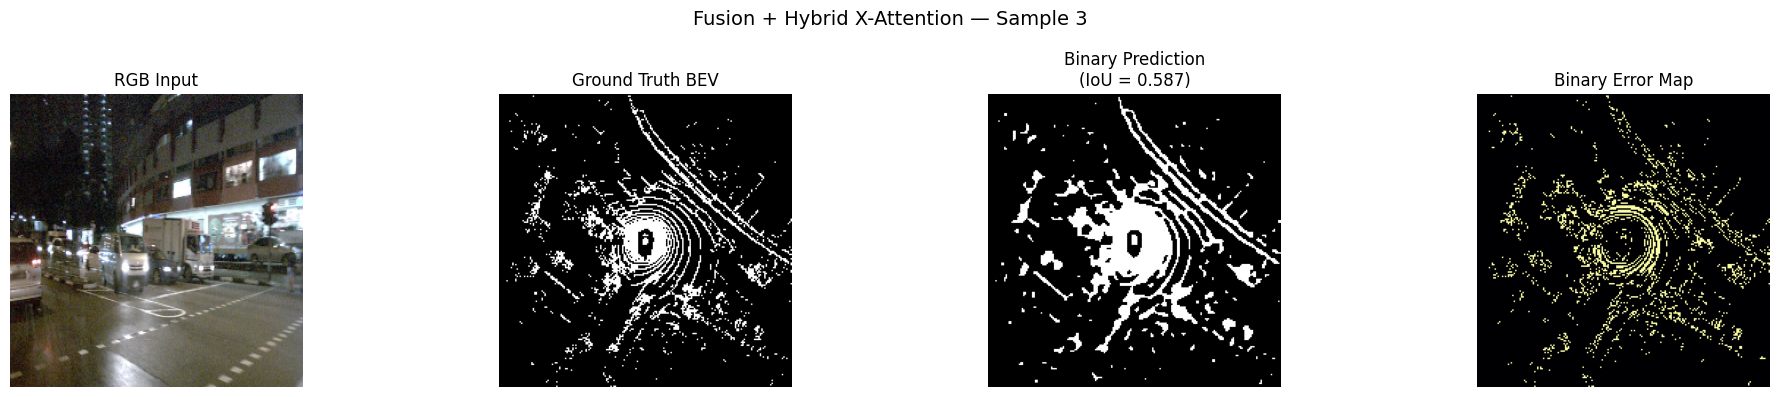

In [ ]:
# ============================================================
# Qualitative Evaluation
#
# Visualize representative validation samples to assess the
# qualitative performance of the Fusion + Hybrid X-Attention
# model.
#
# For each sample, the following are displayed:
#   • RGB input
#   • Ground-truth BEV occupancy map
#   • Predicted binary occupancy map
#   • Binary error map
# ============================================================

import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


# ---------------------------------------------------
# Load best-performing checkpoint
# ---------------------------------------------------
checkpoint_path = (
    "checkpoints/fusion_hybrid_xattn_best.pth"
)

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
    )
)

model.eval()


# ---------------------------------------------------
# Compute binary Intersection-over-Union
# ---------------------------------------------------
def compute_iou(
    pred,
    target,
    thresh=0.5,
):
    """
    Compute the binary Intersection-over-Union (IoU)
    between a predicted BEV occupancy map and the
    corresponding ground-truth map.
    """

    pred_bin = (
        pred > thresh
    ).astype(np.uint8)

    target_bin = (
        target > 0.5
    ).astype(np.uint8)

    intersection = np.logical_and(
        pred_bin,
        target_bin,
    ).sum()

    union = np.logical_or(
        pred_bin,
        target_bin,
    ).sum()

    return intersection / (union + 1e-6)


# ---------------------------------------------------
# Randomly sample validation examples
# ---------------------------------------------------
NUM_SAMPLES = 3

sample_indices = random.sample(
    range(len(val_set)),
    NUM_SAMPLES,
)


# ---------------------------------------------------
# Visualize predictions
# ---------------------------------------------------
for sample_num, idx in enumerate(
    sample_indices,
    start=1,
):

    rgb, bev, imu = val_set[idx]

    rgb_input = rgb.unsqueeze(0).to(device)
    bev_input = bev.unsqueeze(0).to(device)
    imu_input = imu.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = model(
            rgb_input,
            bev_input,
            imu_input,
        )

        probabilities = torch.sigmoid(
            logits
        )

        # ---------------------------------------------
        # Match prediction resolution to the
        # ground-truth BEV occupancy map.
        # ---------------------------------------------
        if probabilities.shape[-2:] != bev_input.shape[-2:]:

            probabilities = F.interpolate(
                probabilities,
                size=bev_input.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

    pred_np = probabilities.squeeze().cpu().numpy()

    gt_np = bev.squeeze().cpu().numpy()

    rgb_np = np.transpose(
        rgb.cpu().numpy(),
        (1, 2, 0),
    )

    # Recover display range
    rgb_np = (
        (rgb_np + 1.0) / 2.0
    ).clip(0, 1)

    pred_bin = (
        pred_np > 0.5
    ).astype(np.float32)

    iou = compute_iou(
        pred_np,
        gt_np,
    )

    error_map = np.abs(
        pred_bin - gt_np
    )

    # ---------------------------------------------------
    # Visualization
    # ---------------------------------------------------
    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 4),
    )

    axes[0].imshow(
        rgb_np,
    )
    axes[0].set_title(
        "RGB Input"
    )
    axes[0].axis(
        "off"
    )

    axes[1].imshow(
        gt_np,
        cmap="gray",
    )
    axes[1].set_title(
        "Ground Truth BEV"
    )
    axes[1].axis(
        "off"
    )

    axes[2].imshow(
        pred_bin,
        cmap="gray",
    )
    axes[2].set_title(
        f"Binary Prediction\n(IoU = {iou:.3f})"
    )
    axes[2].axis(
        "off"
    )

    axes[3].imshow(
        error_map,
        cmap="inferno",
    )
    axes[3].set_title(
        "Binary Error Map"
    )
    axes[3].axis(
        "off"
    )

    plt.suptitle(
        f"Fusion + Hybrid X-Attention — Sample {sample_num}",
        fontsize=14,
    )

    plt.tight_layout()

    plt.show()

# Error Analysis

To better understand model behaviour, representative
validation examples corresponding to the lowest,
median, and highest IoU scores are inspected.

This analysis highlights common failure modes as well as
situations in which the model performs particularly well.

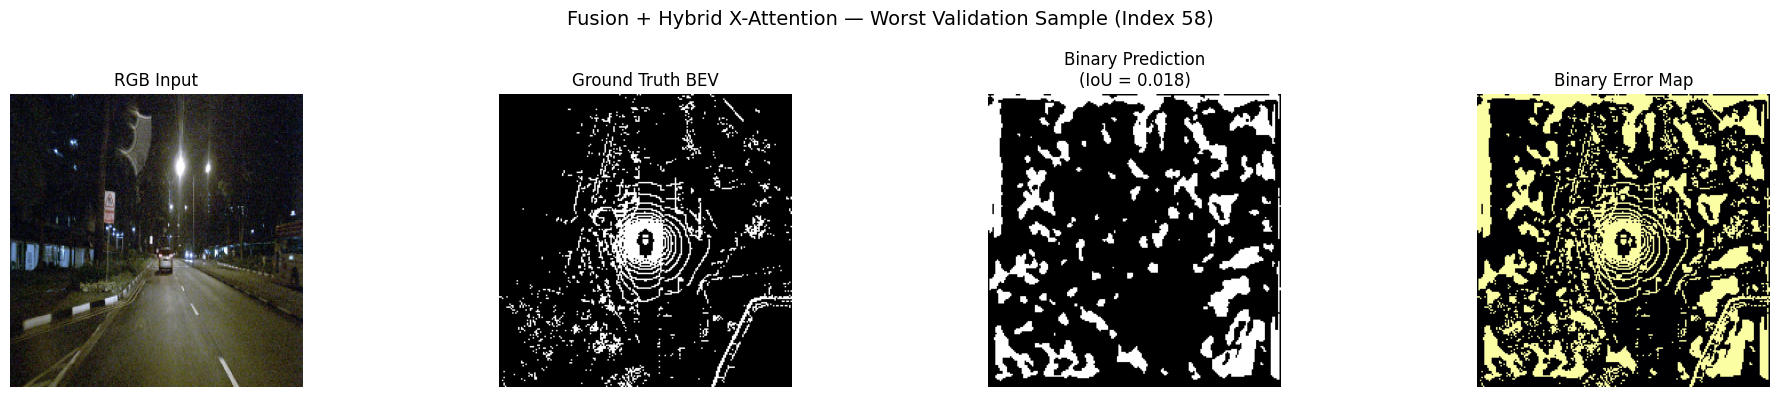

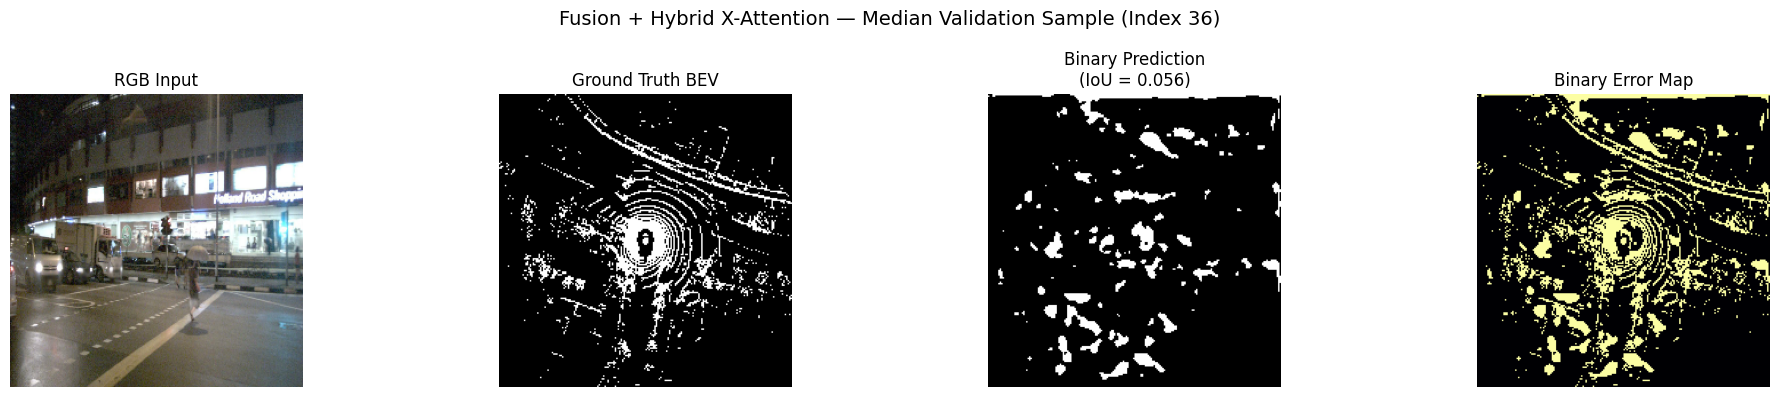

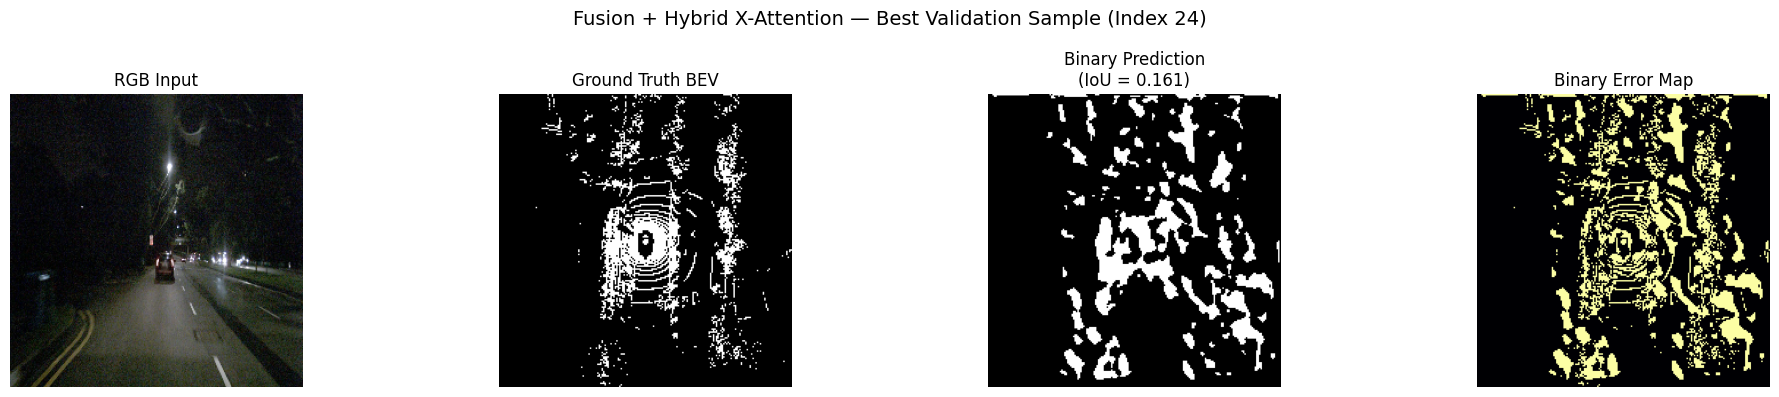

In [10]:
# ============================================================
# Error Analysis
#
# Analyze representative validation examples corresponding
# to the worst, median, and best IoU scores obtained by the
# Fusion + Hybrid X-Attention model.
#
# Examining representative failure and success cases provides
# insight into model behavior beyond aggregate quantitative
# metrics.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


# ---------------------------------------------------
# Compute binary Intersection-over-Union (IoU)
# ---------------------------------------------------
def compute_iou(
    pred,
    target,
    thresh=0.5,
):
    """
    Compute the binary Intersection-over-Union (IoU)
    between a predicted BEV occupancy map and its
    corresponding ground-truth map.
    """

    pred_bin = (
        pred > thresh
    ).astype(np.uint8)

    target_bin = (
        target > 0.5
    ).astype(np.uint8)

    intersection = np.logical_and(
        pred_bin,
        target_bin,
    ).sum()

    union = np.logical_or(
        pred_bin,
        target_bin,
    ).sum()

    return intersection / (union + 1e-6)


# ---------------------------------------------------
# Evaluate every validation sample
# ---------------------------------------------------
sample_results = []

model.eval()

with torch.no_grad():

    for idx in range(len(val_set)):

        rgb, bev, imu = val_set[idx]

        rgb_input = rgb.unsqueeze(0).to(device)
        bev_input = bev.unsqueeze(0).to(device)
        imu_input = imu.unsqueeze(0).to(device)

        logits = model(
            rgb_input,
            bev_input,
            imu_input,
        )

        probabilities = torch.sigmoid(
            logits
        )

        # ---------------------------------------------
        # Match prediction resolution to the
        # ground-truth BEV occupancy map.
        # ---------------------------------------------
        if probabilities.shape[-2:] != bev_input.shape[-2:]:

            probabilities = F.interpolate(
                probabilities,
                size=bev_input.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        pred_np = probabilities.squeeze().cpu().numpy()

        gt_np = bev.squeeze().cpu().numpy()

        iou = compute_iou(
            pred_np,
            gt_np,
        )

        sample_results.append(
            {
                "index": idx,
                "iou": iou,
                "rgb": rgb,
                "gt": gt_np,
                "pred": pred_np,
            }
        )


# ---------------------------------------------------
# Rank validation samples by IoU
# ---------------------------------------------------
sample_results.sort(
    key=lambda sample: sample["iou"],
)

selected_samples = [

    (
        "Worst",
        sample_results[0],
    ),

    (
        "Median",
        sample_results[
            len(sample_results) // 2
        ],
    ),

    (
        "Best",
        sample_results[-1],
    ),
]


# ---------------------------------------------------
# Visualize representative examples
# ---------------------------------------------------
for title, sample in selected_samples:

    rgb_np = np.transpose(
        sample["rgb"].cpu().numpy(),
        (1, 2, 0),
    )

    rgb_np = (
        (rgb_np + 1.0) / 2.0
    ).clip(0, 1)

    pred_bin = (
        sample["pred"] > 0.5
    ).astype(np.float32)

    error_map = np.abs(
        pred_bin - sample["gt"]
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 4),
    )

    axes[0].imshow(
        rgb_np,
    )
    axes[0].set_title(
        "RGB Input"
    )
    axes[0].axis(
        "off"
    )

    axes[1].imshow(
        sample["gt"],
        cmap="gray",
    )
    axes[1].set_title(
        "Ground Truth BEV"
    )
    axes[1].axis(
        "off"
    )

    axes[2].imshow(
        pred_bin,
        cmap="gray",
    )
    axes[2].set_title(
        f"Binary Prediction\n(IoU = {sample['iou']:.3f})"
    )
    axes[2].axis(
        "off"
    )

    axes[3].imshow(
        error_map,
        cmap="inferno",
    )
    axes[3].set_title(
        "Binary Error Map"
    )
    axes[3].axis(
        "off"
    )

    plt.suptitle(
        f"Fusion + Hybrid X-Attention — {title} Validation Sample "
        f"(Index {sample['index']})",
        fontsize=14,
    )

    plt.tight_layout()

    plt.show()

# Experimental Conclusions

The Fusion Baseline achieved the strongest overall
performance on this dataset, providing the highest
segmentation accuracy while maintaining a lightweight
architecture.

The Fusion + Hybrid X-Attention model explored a more
expressive cross-modal fusion strategy. Although it
introduced additional representational capacity, it did
not surpass the baseline under the current experimental
setting.

These experiments illustrate the trade-off between model
complexity and predictive performance, motivating the
selection of the Fusion Baseline for subsequent
deployment and engineering analyses.